In [3]:
!nvidia-smi

Thu Oct  8 07:15:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P0             27W /   70W |     105MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
from numba import cuda
import numpy as np
import time
import math

device = cuda.get_current_device()

name = device.name
if isinstance(name, bytes):
    name = name.decode("utf-8")

print("Device Name:", name)
print("Compute Capability:", device.compute_capability)
print("Multiprocessor Count:", device.MULTIPROCESSOR_COUNT)
print("Max Threads Per Block:", device.MAX_THREADS_PER_BLOCK)
print("Max Block Dimensions:",
      device.MAX_BLOCK_DIM_X,
      device.MAX_BLOCK_DIM_Y,
      device.MAX_BLOCK_DIM_Z)
print("Warp Size:", device.WARP_SIZE)

Device Name: Tesla T4
Compute Capability: ComputeCapability(major=7, minor=5)
Multiprocessor Count: 40
Max Threads Per Block: 1024
Max Block Dimensions: 1024 1024 64
Warp Size: 32


In [5]:
import numpy as np
import time
from numba import cuda

# CPU: Pure Python loop
def double_cpu_pure(arr):
    out = np.empty_like(arr)
    for i in range(len(arr)):
        out[i] = arr[i] * 2.0
    return out

# GPU: CUDA kernel
@cuda.jit
def double_gpu_kernel(d_in, d_out):
    idx = cuda.grid(1)

    if idx < d_in.shape[0]:
        d_out[idx] = d_in[idx] * 2.0

print("CPU and GPU functions initialized.")

CPU and GPU functions initialized.


In [6]:
def benchmark_run(N, student_id_seed=230103254):
    np.random.seed(student_id_seed)
    h_in = np.random.rand(N).astype(np.float32)

    # CPU measurement
    if N <= 1_000_000:
        t0 = time.perf_counter()
        cpu_out = double_cpu_pure(h_in)
        cpu_time_ms = (time.perf_counter() - t0) * 1000
    else:
        cpu_time_ms = float("nan")

    threads_per_block = 256
    blocks_per_grid = (
        N + threads_per_block - 1
    ) // threads_per_block

    # Warmup GPU compilation
    d_warmup = cuda.to_device(
        np.ones(10, dtype=np.float32)
    )
    double_gpu_kernel[1, 32](d_warmup, d_warmup)
    cuda.synchronize()

    # GPU total: transfer + kernel + transfer
    t0 = time.perf_counter()

    d_in = cuda.to_device(h_in)
    d_out = cuda.device_array_like(d_in)

    double_gpu_kernel[
        blocks_per_grid, threads_per_block
    ](d_in, d_out)

    h_out = d_out.copy_to_host()
    cuda.synchronize()

    gpu_total_ms = (
        time.perf_counter() - t0
    ) * 1000

    # GPU kernel-only measurement
    t0 = time.perf_counter()

    double_gpu_kernel[
        blocks_per_grid, threads_per_block
    ](d_in, d_out)

    cuda.synchronize()

    gpu_compute_ms = (
        time.perf_counter() - t0
    ) * 1000

    # Verify correctness
    assert np.allclose(h_out, h_in * 2)

    return cpu_time_ms, gpu_total_ms, gpu_compute_ms

In [7]:
import pandas as pd

sizes = [
    100,
    1000,
    10000,
    100000,
    1000000,
    5000000,
    10000000
]

results = []

for N in sizes:
    cpu_ms, gpu_total, gpu_kernel = benchmark_run(N)

    if np.isnan(cpu_ms):
        winner = "N/A"
    elif cpu_ms < gpu_total:
        winner = "CPU"
    else:
        winner = "GPU"

    results.append({
        "N": N,
        "CPU Time (ms)": cpu_ms,
        "GPU Total (ms)": gpu_total,
        "GPU Kernel Only (ms)": gpu_kernel,
        "Winner": winner
    })

df = pd.DataFrame(results)

print(df.to_string(index=False))

valid = df.dropna(subset=["CPU Time (ms)"])
faster = valid[
    valid["GPU Total (ms)"] < valid["CPU Time (ms)"]
]

if len(faster) > 0:
    CROSSOVER_N = int(faster.iloc[0]["N"])
    print("\nObserved Crossover N*:", CROSSOVER_N)
else:
    CROSSOVER_N = None
    print("\nNo crossover found in measured CPU sizes.")

/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 40 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


       N  CPU Time (ms)  GPU Total (ms)  GPU Kernel Only (ms) Winner
     100       0.051173        1.233448              0.097351    CPU
    1000       0.607945        0.944415              0.100611    CPU
   10000       4.995591        0.727034              0.104109    GPU
  100000      59.788660        1.082221              0.106156    GPU
 1000000     498.785479        5.632017              0.147668    GPU
 5000000            NaN       15.121944              0.305526    N/A
10000000            NaN       28.356628              0.519577    N/A

Observed Crossover N*: 10000


In [8]:
@cuda.jit
def defective_kernel(d_arr):
    idx = cuda.grid(1)
    d_arr[idx] = 999.0

N = 1000
h_arr = np.zeros(N, dtype=np.float32)
d_arr = cuda.to_device(h_arr)

threads_per_block = 256
blocks_per_grid = 4

print("Launching 1024 threads for 1000 elements...")

try:
    defective_kernel[
        blocks_per_grid, threads_per_block
    ](d_arr)

    cuda.synchronize()

    h_result = d_arr.copy_to_host()

    print("Execution completed.")
    print("Elements:", len(h_result))
    print("Last element:", h_result[-1])

except Exception as e:
    print("CUDA ERROR:")
    print(type(e).__name__)
    print(str(e))

Launching 1024 threads for 1000 elements...
Execution completed.
Elements: 1000
Last element: 999.0


/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


In [9]:
@cuda.jit
def inspect_threads_kernel(
    log_block, log_thread,
    log_global, log_active, N
):
    t_idx = cuda.threadIdx.x
    b_idx = cuda.blockIdx.x
    g_idx = cuda.grid(1)

    if g_idx < log_block.shape[0]:
        log_block[g_idx] = b_idx
        log_thread[g_idx] = t_idx
        log_global[g_idx] = g_idx
        log_active[g_idx] = 1 if g_idx < N else 0


N = 37
threads_per_block = 8
blocks_per_grid = (
    N + threads_per_block - 1
) // threads_per_block

total_threads = blocks_per_grid * threads_per_block

log_b = cuda.device_array(total_threads, dtype=np.int32)
log_t = cuda.device_array(total_threads, dtype=np.int32)
log_g = cuda.device_array(total_threads, dtype=np.int32)
log_a = cuda.device_array(total_threads, dtype=np.int32)

inspect_threads_kernel[
    blocks_per_grid, threads_per_block
](log_b, log_t, log_g, log_a, N)

cuda.synchronize()

b = log_b.copy_to_host()
t = log_t.copy_to_host()
g = log_g.copy_to_host()
a = log_a.copy_to_host()

for i in range(32, 40):
    status = "ACTIVE" if a[i] == 1 else "IDLE"
    print(
        f"Global={g[i]}, Block={b[i]}, "
        f"Thread={t[i]}, Status={status}"
    )

print("\nTotal Blocks:", blocks_per_grid)
print("Total Threads:", total_threads)
print("Active Threads:", int(a.sum()))
print("Idle Threads:", int(total_threads - a.sum()))

Global=32, Block=4, Thread=0, Status=ACTIVE
Global=33, Block=4, Thread=1, Status=ACTIVE
Global=34, Block=4, Thread=2, Status=ACTIVE
Global=35, Block=4, Thread=3, Status=ACTIVE
Global=36, Block=4, Thread=4, Status=ACTIVE
Global=37, Block=4, Thread=5, Status=IDLE
Global=38, Block=4, Thread=6, Status=IDLE
Global=39, Block=4, Thread=7, Status=IDLE

Total Blocks: 5
Total Threads: 40
Active Threads: 37
Idle Threads: 3


/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 5 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


In [10]:
@cuda.jit
def naive_sum_kernel(d_arr, d_total):
    idx = cuda.grid(1)

    if idx < d_arr.shape[0]:
        d_total[0] += d_arr[idx]


@cuda.jit
def atomic_sum_kernel(d_arr, d_total):
    idx = cuda.grid(1)

    if idx < d_arr.shape[0]:
        cuda.atomic.add(d_total, 0, d_arr[idx])

print("Naive and Atomic kernels initialized.")

Naive and Atomic kernels initialized.


In [11]:
N = 50000

h_arr = np.ones(N, dtype=np.float32)
d_arr = cuda.to_device(h_arr)

threads = 256
blocks = (N + threads - 1) // threads

# Warmup compilation
warm_total = cuda.to_device(
    np.zeros(1, dtype=np.float32)
)

naive_sum_kernel[blocks, threads](d_arr, warm_total)
cuda.synchronize()

warm_total.copy_to_device(
    np.zeros(1, dtype=np.float32)
)

atomic_sum_kernel[blocks, threads](d_arr, warm_total)
cuda.synchronize()

naive_times = []
naive_outputs = []

for trial in range(5):
    d_total = cuda.to_device(
        np.zeros(1, dtype=np.float32)
    )

    start = time.perf_counter()

    naive_sum_kernel[blocks, threads](d_arr, d_total)
    cuda.synchronize()

    elapsed = (time.perf_counter() - start) * 1000

    result = float(d_total.copy_to_host()[0])
    deviation = 50000.0 - result

    naive_times.append(elapsed)
    naive_outputs.append(result)

    print(
        f"Trial {trial+1}: "
        f"Output={result}, "
        f"Lost Updates={deviation}, "
        f"Time={elapsed:.4f} ms"
    )

print("\nAverage Naive Time:",
      np.mean(naive_times), "ms")

Trial 1: Output=2.0, Lost Updates=49998.0, Time=0.2507 ms
Trial 2: Output=2.0, Lost Updates=49998.0, Time=0.2140 ms
Trial 3: Output=2.0, Lost Updates=49998.0, Time=0.1824 ms
Trial 4: Output=2.0, Lost Updates=49998.0, Time=0.2079 ms
Trial 5: Output=2.0, Lost Updates=49998.0, Time=0.1744 ms

Average Naive Time: 0.20587519998116477 ms


In [12]:
atomic_times = []

for trial in range(5):
    d_total = cuda.to_device(
        np.zeros(1, dtype=np.float32)
    )

    start = time.perf_counter()

    atomic_sum_kernel[blocks, threads](d_arr, d_total)
    cuda.synchronize()

    elapsed = (time.perf_counter() - start) * 1000

    atomic_times.append(elapsed)

    result = float(d_total.copy_to_host()[0])

    print(
        f"Atomic Trial {trial+1}: "
        f"Sum={result}, Time={elapsed:.4f} ms"
    )

print("\nExpected Sum: 50000.0")
print("Atomic Sum Output:", result)

print("Average Naive Time:",
      np.mean(naive_times), "ms")

print("Average Atomic Time:",
      np.mean(atomic_times), "ms")

Atomic Trial 1: Sum=50000.0, Time=0.4825 ms
Atomic Trial 2: Sum=50000.0, Time=0.3766 ms
Atomic Trial 3: Sum=50000.0, Time=0.2923 ms
Atomic Trial 4: Sum=50000.0, Time=1.2310 ms
Atomic Trial 5: Sum=50000.0, Time=0.3467 ms

Expected Sum: 50000.0
Atomic Sum Output: 50000.0
Average Naive Time: 0.20587519998116477 ms
Average Atomic Time: 0.5458115999886104 ms


In [13]:
import math
import matplotlib.pyplot as plt

@cuda.jit
def radial_vignette_2d(
    d_canvas, width, height, center_x, center_y
):
    x, y = cuda.grid(2)

    if x < width and y < height:
        dx = float(x - center_x)
        dy = float(y - center_y)

        dist = math.sqrt(dx * dx + dy * dy)

        max_dist = math.sqrt(
            float(center_x**2 + center_y**2)
        )

        intensity = 1.0 - (dist / max_dist)

        if intensity < 0.0:
            intensity = 0.0

        d_canvas[y, x] = intensity


WIDTH, HEIGHT = 1024, 1024

canvas = np.zeros(
    (HEIGHT, WIDTH),
    dtype=np.float32
)

d_canvas = cuda.to_device(canvas)

threads_2d = (16, 16)

blocks_2d = (
    (WIDTH + threads_2d[0] - 1) // threads_2d[0],
    (HEIGHT + threads_2d[1] - 1) // threads_2d[1]
)

radial_vignette_2d[
    blocks_2d, threads_2d
](
    d_canvas,
    WIDTH,
    HEIGHT,
    WIDTH // 2,
    HEIGHT // 2
)

cuda.synchronize()

result_canvas = d_canvas.copy_to_host()

print("Shape:", result_canvas.shape)
print("Blocks X:", blocks_2d[0])
print("Blocks Y:", blocks_2d[1])
print("Total Blocks:", blocks_2d[0] * blocks_2d[1])
print("Center:", result_canvas[512, 512])
print("Corner:", result_canvas[0, 0])

Shape: (1024, 1024)
Blocks X: 64
Blocks Y: 64
Total Blocks: 4096
Center: 1.0
Corner: 0.0


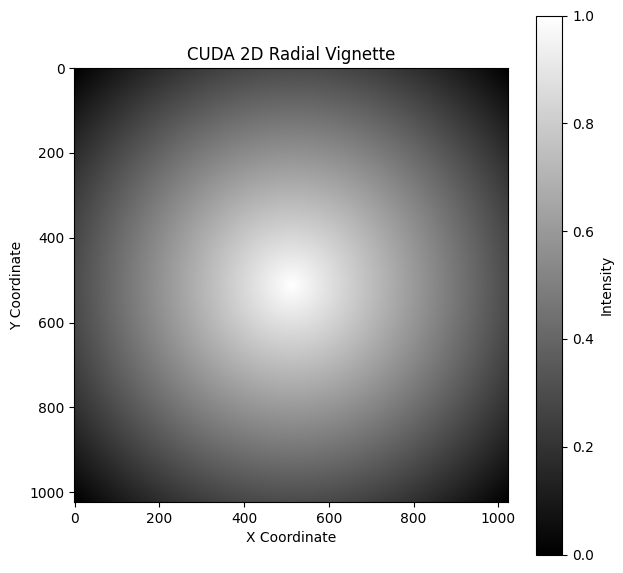

In [14]:
plt.figure(figsize=(7, 7))

plt.imshow(result_canvas, cmap="gray")

plt.title("CUDA 2D Radial Vignette")
plt.colorbar(label="Intensity")

plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")

plt.show()

In [15]:
import hashlib

def generate_lab_checksum(
    student_id_str,
    d_canvas,
    exp_table_crossover
):
    h = hashlib.sha256()

    h.update(
        student_id_str.strip().encode("utf-8")
    )

    gpu_name = cuda.get_current_device().name

    if isinstance(gpu_name, str):
        gpu_name = gpu_name.encode("utf-8")

    h.update(gpu_name)

    h.update(
        d_canvas.copy_to_host()[:10, :10].tobytes()
    )

    h.update(
        str(exp_table_crossover).encode("utf-8")
    )

    digest = h.hexdigest()[:16].upper()

    print("=" * 60)
    print("OFFICIAL VERIFICATION CHECKSUM TOKEN:")
    print(digest)
    print("=" * 60)

    return digest


STUDENT_ID = "230103254"

# Use the measured crossover from Section 2
if CROSSOVER_N is None:
    print("No measured crossover point available.")
    print("Review Section 2 before final submission.")
else:
    CHECKSUM = generate_lab_checksum(
        STUDENT_ID,
        d_canvas,
        CROSSOVER_N
    )

OFFICIAL VERIFICATION CHECKSUM TOKEN:
272FE4A06FB1AFDA
